Домашнее задание №17. Кручинин С.В.
Урок 46.

Запускать из папки дз17. Файл priznaki.csv лежит рядом.

Вопрос:
На основе датасета, который был использован для промежуточной аттестации.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv('priznaki.csv')
print('всего строк', len(df))
df = df[df['otsenka'].notna()].copy()
print('с оценкой', len(df))


всего строк 96
с оценкой 81


Ответ:
Было 96 строк. Где книга на руках, оценки нет, эти строки убрал. Осталось 81.

Вопрос:
Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных.

Ответ:
Таргет otsenka, оценка от 1 до 5, это число.
Объясняющие: vozrast, tema_sovpala, zhanr_sovpal, skok_brali.

Вопрос:
Постройте точечные диаграммы для таргета и каждой фичи, опишите форму взаимосвязи.

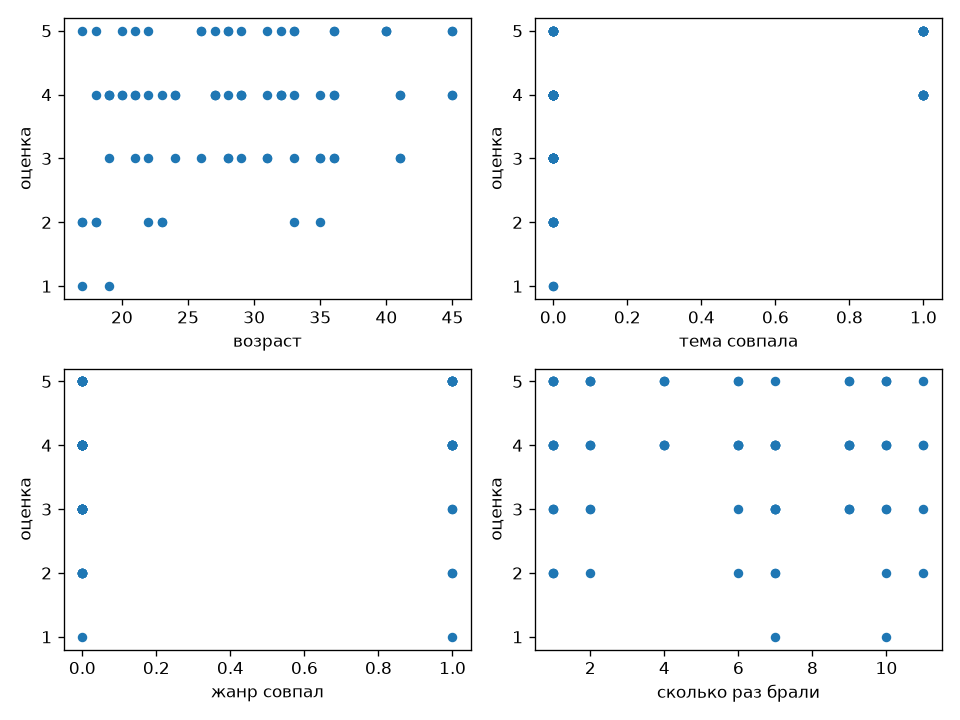

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
names = [('vozrast','возраст'), ('tema_sovpala','тема совпала'), ('zhanr_sovpal','жанр совпал'), ('skok_brali','сколько раз брали')]
for ax, (c, name) in zip(axes.ravel(), names):
    ax.scatter(df[c], df['otsenka'], s=22)
    ax.set_xlabel(name)
    ax.set_ylabel('оценка')
plt.tight_layout()
plt.savefig('dz17_scatter.png', dpi=120)
plt.show()


Ответ:
Возраст: облако, слабый подъём слева направо, изгиба нет.
Тема совпала: две полосы, 0 и 1. При 0 оценки от 1 до 5, средняя 3.51. При 1 оценки от 4 до 5, средняя 4.55. Если тема совпала, оценки выше.
Жанр совпал: тоже две полосы, разброс с обеих сторон похожий, связи почти нет.
Сколько раз брали: точки размазаны по всем оценкам, наклона нет.

Вопрос:
Разделите датасет на обучающую и тестовую выборки.

In [3]:
train, test = train_test_split(df, test_size=0.33, random_state=42)
print('обучение', len(train), 'тест', len(test))


обучение 54 тест 27


Ответ:
Как в тетради: test_size = 0.33, random_state = 42. Обучение 54, тест 27. Дальше все модели на этом делении.

Вопрос:
Сделайте масштабирование объясняющих переменных.

In [4]:
def r(v):
    x = round(float(v), 3)
    return 0.0 if x == 0 else x

def take(frame, kind):
    if kind == 'возраст':
        return frame[['vozrast']]
    if kind == 'тема':
        return frame[['tema_sovpala']]
    if kind == 'возраст и тема':
        return frame[['vozrast', 'tema_sovpala']]
    if kind == 'все четыре':
        return frame[['vozrast', 'tema_sovpala', 'zhanr_sovpal', 'skok_brali']]
    if kind == 'ln(возраст)':
        return np.log(frame[['vozrast']])
    if kind == 'возраст^2':
        return (frame['vozrast'] ** 2).to_numpy().reshape(-1, 1)
    if kind == '1/возраст':
        return 1 / frame[['vozrast']]

cols = ['vozrast', 'tema_sovpala', 'zhanr_sovpal', 'skok_brali']
scaler4 = StandardScaler().fit(train[cols])
print('среднее', [r(v) for v in scaler4.mean_])
print('масштаб', [r(v) for v in scaler4.scale_])


среднее [28.704, 0.259, 0.333, 5.278]
масштаб [7.591, 0.438, 0.471, 3.525]


Ответ:
Среднее на обучении, четыре признака: возраст 28.704, тема 0.259, жанр 0.333, сколько брали 5.278.
Масштаб: 7.591, 0.438, 0.471, 3.525.
Для ln(возраст), квадрата и 1/возраст масштаб свой, по этому столбцу. Веса моделей ниже уже после масштаба.

Вопрос:
Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающей выборке.

In [5]:
kinds = ['возраст', 'тема', 'возраст и тема', 'все четыре', 'ln(возраст)', 'возраст^2', '1/возраст']
preds = {}
for kind in kinds:
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(take(train, kind))
    Xte = scaler.transform(take(test, kind))
    for name, Cls in (('Lasso', Lasso), ('Ridge', Ridge)):
        model = Cls(alpha=0.1)
        model.fit(Xtr, train['otsenka'])
        preds[(name, kind)] = model.predict(Xte)
        print(name, kind)
        print('w0', r(model.intercept_), 'w', [r(v) for v in model.coef_])


Lasso возраст
w0 3.796 w [0.248]
Ridge возраст
w0 3.796 w [0.348]
Lasso тема
w0 3.796 w [0.359]
Ridge тема
w0 3.796 w [0.458]
Lasso возраст и тема
w0 3.796 w [0.209, 0.334]
Ridge возраст и тема
w0 3.796 w [0.298, 0.423]
Lasso все четыре
w0 3.796 w [0.237, 0.391, -0.126, 0.0]
Ridge все четыре
w0 3.796 w [0.376, 0.585, -0.356, 0.009]
Lasso ln(возраст)
w0 3.796 w [0.281]
Ridge ln(возраст)
w0 3.796 w [0.381]
Lasso возраст^2
w0 3.796 w [0.215]
Ridge возраст^2
w0 3.796 w [0.314]
Lasso 1/возраст
w0 3.796 w [-0.311]
Ridge 1/возраст
w0 3.796 w [-0.41]


Ответ:
alpha = 0.1. Наборы: возраст; тема; возраст и тема; все четыре.
Формы возраста: прямая, ln(возраст), возраст в квадрате, 1/возраст. Веса после масштаба.
Lasso, возраст: w0 3.796, w 0.248
Ridge, возраст: w0 3.796, w 0.348
Lasso, тема: w0 3.796, w 0.359
Ridge, тема: w0 3.796, w 0.458
Lasso, возраст и тема: w0 3.796, w 0.209, 0.334
Ridge, возраст и тема: w0 3.796, w 0.298, 0.423
Lasso, все четыре: w0 3.796, w 0.237, 0.391, -0.126, 0.0
Ridge, все четыре: w0 3.796, w 0.376, 0.585, -0.356, 0.009
Lasso, ln(возраст): w0 3.796, w 0.281
Ridge, ln(возраст): w0 3.796, w 0.381
Lasso, возраст^2: w0 3.796, w 0.215
Ridge, возраст^2: w0 3.796, w 0.314
Lasso, 1/возраст: w0 3.796, w -0.311
Ridge, 1/возраст: w0 3.796, w -0.41

Вопрос:
Сделайте предсказания целевой переменной для тестовой выборки.

In [6]:
for name in ('Lasso', 'Ridge'):
    tab = pd.DataFrame({'факт': test['otsenka'].to_numpy()})
    for kind in kinds:
        tab[kind] = preds[(name, kind)].round(2)
    print(name)
    print(tab.to_string(index=False))


Lasso
 факт  возраст  тема  возраст и тема  все четыре  ln(возраст)  возраст^2  1/возраст
  1.0     3.41  3.58            3.28        3.29         3.27       3.53       3.11
  3.0     3.58  3.58            3.41        3.44         3.55       3.61       3.54
  3.0     3.77  3.58            3.58        3.63         3.81       3.75       3.85
  4.0     3.51  3.58            3.36        3.38         3.45       3.58       3.39
  4.0     3.90  3.58            3.69        3.76         3.95       3.86       3.99
  5.0     3.94  3.58            3.72        3.79         3.98       3.89       4.02
  2.0     4.00  3.58            3.77        3.85         4.05       3.95       4.08
  5.0     3.45  3.58            3.30        3.32         3.33       3.54       3.21
  3.0     3.54  3.58            3.39        3.41         3.50       3.59       3.47
  5.0     4.17  3.58            3.91        4.01         4.19       4.13       4.19
  2.0     3.41  3.58            3.28        3.29         3.27       3.

Ответ:
Прогноз Lasso и Ridge на 27 строках теста. Таблицы выше.

Вопрос:
Рассчитайте метрики качества.

In [7]:
y_true = test['otsenka']
for name in ('Lasso', 'Ridge'):
    for kind in kinds:
        y_pred = preds[(name, kind)]
        print(name, kind)
        print('MSE', round(mean_squared_error(y_true, y_pred), 3),
              'RMSE', round(root_mean_squared_error(y_true, y_pred), 3),
              'MAE', round(mean_absolute_error(y_true, y_pred), 3),
              'MAPE', round(mean_absolute_percentage_error(y_true, y_pred), 3),
              'R2', round(r2_score(y_true, y_pred), 3))


Lasso возраст
MSE 1.164 RMSE 1.079 MAE 0.931 MAPE 0.339 R2 0.007
Lasso тема
MSE 1.001 RMSE 1.001 MAE 0.843 MAPE 0.312 R2 0.145
Lasso возраст и тема
MSE 0.942 RMSE 0.971 MAE 0.832 MAPE 0.302 R2 0.196
Lasso все четыре
MSE 0.981 RMSE 0.99 MAE 0.848 MAPE 0.309 R2 0.163
Lasso ln(возраст)
MSE 1.182 RMSE 1.087 MAE 0.944 MAPE 0.337 R2 -0.009
Lasso возраст^2
MSE 1.151 RMSE 1.073 MAE 0.922 MAPE 0.34 R2 0.018
Lasso 1/возраст
MSE 1.205 RMSE 1.098 MAE 0.956 MAPE 0.335 R2 -0.029
Ridge возраст
MSE 1.199 RMSE 1.095 MAE 0.945 MAPE 0.338 R2 -0.024
Ridge тема
MSE 0.993 RMSE 0.997 MAE 0.836 MAPE 0.306 R2 0.152
Ridge возраст и тема
MSE 0.92 RMSE 0.959 MAE 0.821 MAPE 0.292 R2 0.215
Ridge все четыре
MSE 1.069 RMSE 1.034 MAE 0.895 MAPE 0.319 R2 0.088
Ridge ln(возраст)
MSE 1.236 RMSE 1.112 MAE 0.962 MAPE 0.337 R2 -0.055
Ridge возраст^2
MSE 1.171 RMSE 1.082 MAE 0.929 MAPE 0.339 R2 0.001
Ridge 1/возраст
MSE 1.277 RMSE 1.13 MAE 0.979 MAPE 0.334 R2 -0.09


Ответ:
Lasso, возраст: MSE 1.164, RMSE 1.079, MAE 0.931, MAPE 0.339, R2 0.007
Ridge, возраст: MSE 1.199, RMSE 1.095, MAE 0.945, MAPE 0.338, R2 -0.024
Lasso, тема: MSE 1.001, RMSE 1.001, MAE 0.843, MAPE 0.312, R2 0.145
Ridge, тема: MSE 0.993, RMSE 0.997, MAE 0.836, MAPE 0.306, R2 0.152
Lasso, возраст и тема: MSE 0.942, RMSE 0.971, MAE 0.832, MAPE 0.302, R2 0.196
Ridge, возраст и тема: MSE 0.92, RMSE 0.959, MAE 0.821, MAPE 0.292, R2 0.215
Lasso, все четыре: MSE 0.981, RMSE 0.99, MAE 0.848, MAPE 0.309, R2 0.163
Ridge, все четыре: MSE 1.069, RMSE 1.034, MAE 0.895, MAPE 0.319, R2 0.088
Lasso, ln(возраст): MSE 1.182, RMSE 1.087, MAE 0.944, MAPE 0.337, R2 -0.009
Ridge, ln(возраст): MSE 1.236, RMSE 1.112, MAE 0.962, MAPE 0.337, R2 -0.055
Lasso, возраст^2: MSE 1.151, RMSE 1.073, MAE 0.922, MAPE 0.34, R2 0.018
Ridge, возраст^2: MSE 1.171, RMSE 1.082, MAE 0.929, MAPE 0.339, R2 0.001
Lasso, 1/возраст: MSE 1.205, RMSE 1.098, MAE 0.956, MAPE 0.335, R2 -0.029
Ridge, 1/возраст: MSE 1.277, RMSE 1.13, MAE 0.979, MAPE 0.334, R2 -0.09

Вопрос:
Выберите спецификацию модели с наилучшим качеством.

Ответ:
Лучше Ridge, «возраст и тема». R2 0.215, MSE 0.92.
Lasso на тех же признаках: R2 0.196.
Логарифм, квадрат и 1/возраст на тесте хуже прямой. Все четыре признака тоже хуже. У Lasso на всех четырёх вес числа выдач 0.0.

Вопрос:
Сделайте выводы относительно полученной модели и ее качества.

Ответ:
Модель слабая. R2 0.215, большую часть разброса оценок она не объясняет. MAE 0.821, промах меньше балла. Для точной оценки книги этого мало.

Вопрос:
Разместите блокнот в GitHub и прикрепите ссылку.

Ответ:
Ссылка на блокнот: https://github.com/ubersk-debug/pg-kruchinin/blob/master/дз17/dz17_lasso_ridge.ipynb